 CREDIT SCORING MODEL 

Loading German Credit Dataset...

Dataset Loaded Successfully!
  checking_status  duration                  credit_history  \
0              <0         6  critical/other existing credit   
1        0<=X<200        48                   existing paid   
2     no checking        12  critical/other existing credit   
3              <0        42                   existing paid   
4              <0        24              delayed previously   

               purpose  credit_amount    savings_status employment  \
0             radio/tv           1169  no known savings        >=7   
1             radio/tv           5951              <100     1<=X<4   
2            education           2096              <100     4<=X<7   
3  furniture/equipment           7882              <100     4<=X<7   
4              new car           4870              <100     1<=X<4   

   installment_commitment     personal_status other_parties  ...  \
0                       4         male single

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression
Accuracy : 0.73
Precision: 0.7636363636363637
Recall   : 0.8936170212765957
F1 Score : 0.8235294117647058

Decision Tree
Accuracy : 0.695
Precision: 0.7898550724637681
Recall   : 0.7730496453900709
F1 Score : 0.7813620071684588

Random Forest
Accuracy : 0.785
Precision: 0.7951807228915663
Recall   : 0.9361702127659575
F1 Score : 0.8599348534201955

Model Comparison
                 Model  Accuracy
0  Logistic Regression     0.730
1        Decision Tree     0.695
2        Random Forest     0.785


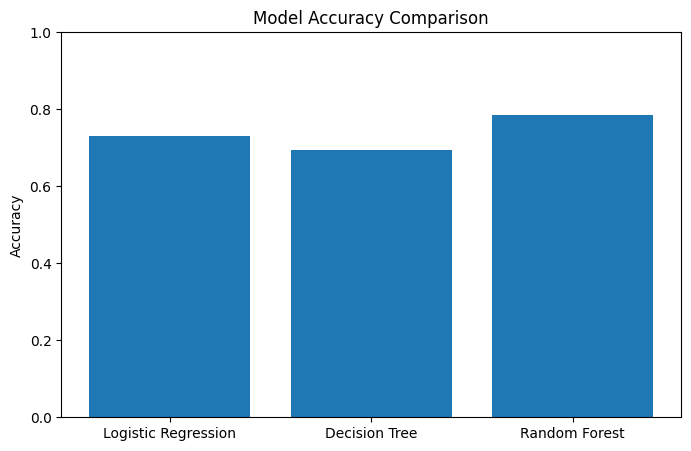

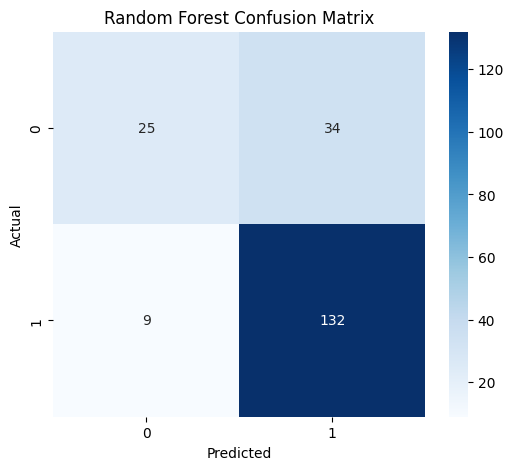


Classification Report
              precision    recall  f1-score   support

           0       0.74      0.42      0.54        59
           1       0.80      0.94      0.86       141

    accuracy                           0.79       200
   macro avg       0.77      0.68      0.70       200
weighted avg       0.78      0.79      0.76       200

ROC-AUC Score : 0.8301478543094122


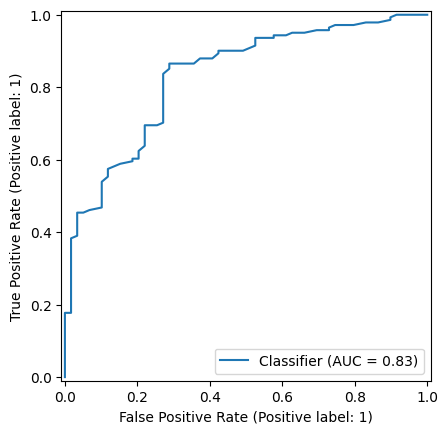

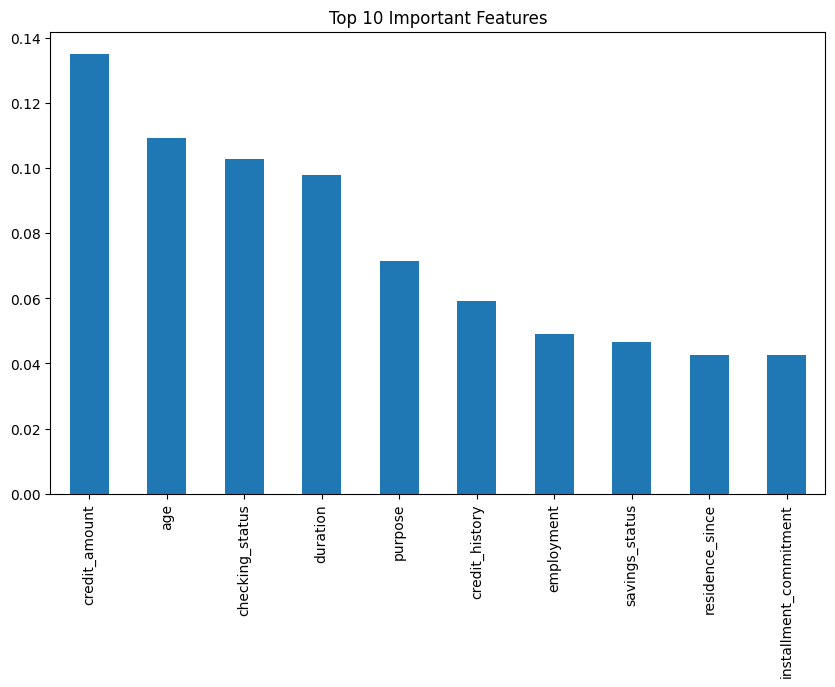


Sample Prediction
Customer is CREDITWORTHY (Good Credit)

Model Saved Successfully as credit_scoring_model.pkl


In [2]:
!pip -q install scikit-learn pandas matplotlib seaborn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

print("="*60)
print(" CREDIT SCORING MODEL ")
print("="*60)

# Load Dataset
print("\nLoading German Credit Dataset...")

data = fetch_openml(name='credit-g', version=1, as_frame=True)

df = data.frame

print("\nDataset Loaded Successfully!")
print(df.head())

# Features and Target
X = df.drop("class", axis=1)
y = df["class"]

# Convert Target
y = y.map({"good":1, "bad":0})

# Encode Categorical Columns
encoder = LabelEncoder()

for col in X.columns:
    if X[col].dtype == object or str(X[col].dtype)=="category":
        X[col] = encoder.fit_transform(X[col].astype(str))

print("\nData Preprocessing Completed!")

# Train Test Split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Samples :",len(X_train))
print("Testing Samples :",len(X_test))


lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
lr_pred = lr.predict(X_test)


dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
dt_pred = dt.predict(X_test)


rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train,y_train)
rf_pred = rf.predict(X_test)


def evaluate(model_name,y_true,y_pred):

    print("\n"+"="*60)
    print(model_name)
    print("="*60)

    print("Accuracy :",accuracy_score(y_true,y_pred))
    print("Precision:",precision_score(y_true,y_pred))
    print("Recall   :",recall_score(y_true,y_pred))
    print("F1 Score :",f1_score(y_true,y_pred))

evaluate("Logistic Regression",y_test,lr_pred)
evaluate("Decision Tree",y_test,dt_pred)
evaluate("Random Forest",y_test,rf_pred)


results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,dt_pred),
        accuracy_score(y_test,rf_pred)
    ]
})

print("\nModel Comparison")
print(results)

# Accuracy Graph
plt.figure(figsize=(8,5))
plt.bar(results["Model"],results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test,rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            cmap="Blues",
            fmt="d")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report")
print(classification_report(y_test,rf_pred))

# ROC Curve
rf_prob = rf.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test,rf_prob)

print("ROC-AUC Score :",roc)

RocCurveDisplay.from_predictions(y_test,rf_prob)
plt.show()

# Feature Importance
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(10).plot(kind="bar")
plt.title("Top 10 Important Features")
plt.show()

# Sample Prediction
sample = X.iloc[[0]]

prediction = rf.predict(sample)

print("\nSample Prediction")

if prediction[0]==1:
    print("Customer is CREDITWORTHY (Good Credit)")
else:
    print("Customer is NOT CREDITWORTHY (Bad Credit)")

# Save Model
joblib.dump(rf,"credit_scoring_model.pkl")

print("\nModel Saved Successfully as credit_scoring_model.pkl")